## **Olalemi Olaoluwakintan Emmanuel**

### **Data Cleaning and Wrangeling**

In [ ]:
#importing dependency
import pandas as pd

#imports dataset into a pandas dataframe

data = pd.read_csv("/content/diabetes_nan.csv")

In [ ]:
#Prints the first five row of the dataset to confirm the right dataset was uploaded.
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,outcome(target)
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [ ]:
#Prints the dimensions of the dataset i.e the number of (rows, columns).
data.shape

(768, 9)

In [ ]:
#Prints a statistical summary of the numerical columns
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,outcome(target)
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
#Prints data types, non-null counts, and memory usage
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   SkinThickness             541 non-null    float64
 4   Insulin                   394 non-null    float64
 5   BMI                       757 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   outcome(target)           768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [ ]:
#Prints a list of the names of all columns in the dataframe
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'outcome(target)'],
      dtype='object')

In [ ]:
#Prints the count of the number missing (null)
missing_values = data.isnull().sum()
print(missing_values)

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
outcome(target)               0
dtype: int64


In [ ]:
# Handle missing values using the median of each column
columns_with_missingValues = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for columns in columns_with_missingValues:
    column_median = data[columns].median()
    data[columns] = data[columns].fillna(column_median)

# Verify that there are no more missing values
print(data.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
outcome(target)             0
dtype: int64


### **Exploratory Data Analysis (EDA)**

##### **Fig 1**

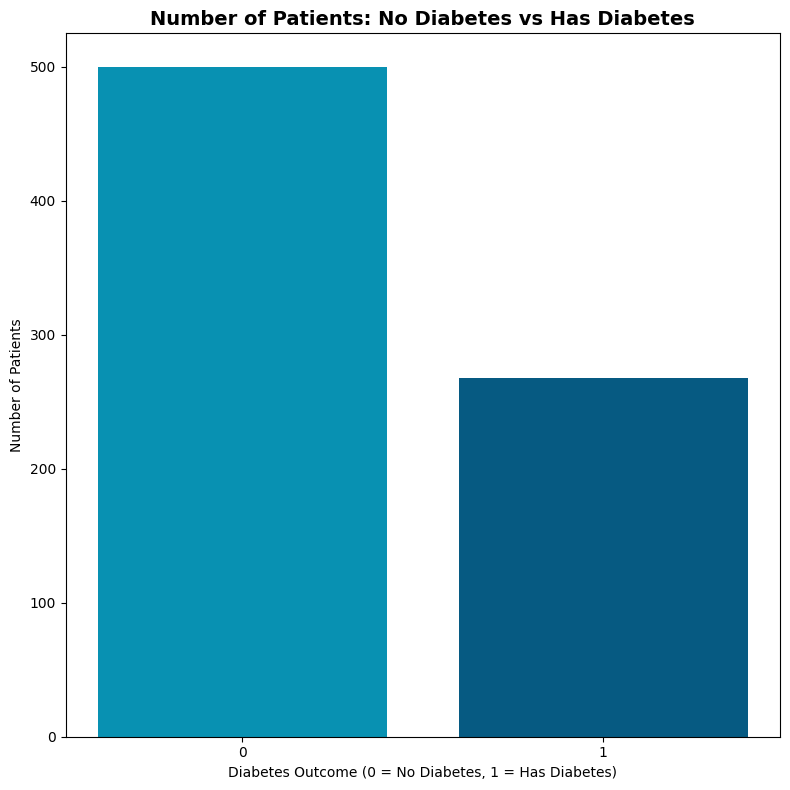

In [ ]:
# Importing dependencies
import matplotlib.pyplot as plt

# Plotting a Bar chart of No Diabetes vs Has Diabetes
outcome_counts = data["outcome(target)"].value_counts()

plt.figure(figsize=(8, 8))
plt.bar(outcome_counts.index.astype(str), outcome_counts.values,
        color=["#0891B2", "#065A82"])

plt.title("Number of Patients: No Diabetes vs Has Diabetes",
          fontsize=14, fontweight="bold")

plt.xlabel("Diabetes Outcome (0 = No Diabetes, 1 = Has Diabetes)")

plt.ylabel("Number of Patients")

plt.tight_layout()

plt.show()

In [ ]:
DiabetesVsNon = data["outcome(target)"].value_counts()
print (DiabetesVsNon)

outcome(target)
0    500
1    268
Name: count, dtype: int64


##### **Fig 2**

/tmp/ipykernel_3810/711070746.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([glucose_no_diabetes, glucose_has_diabetes],


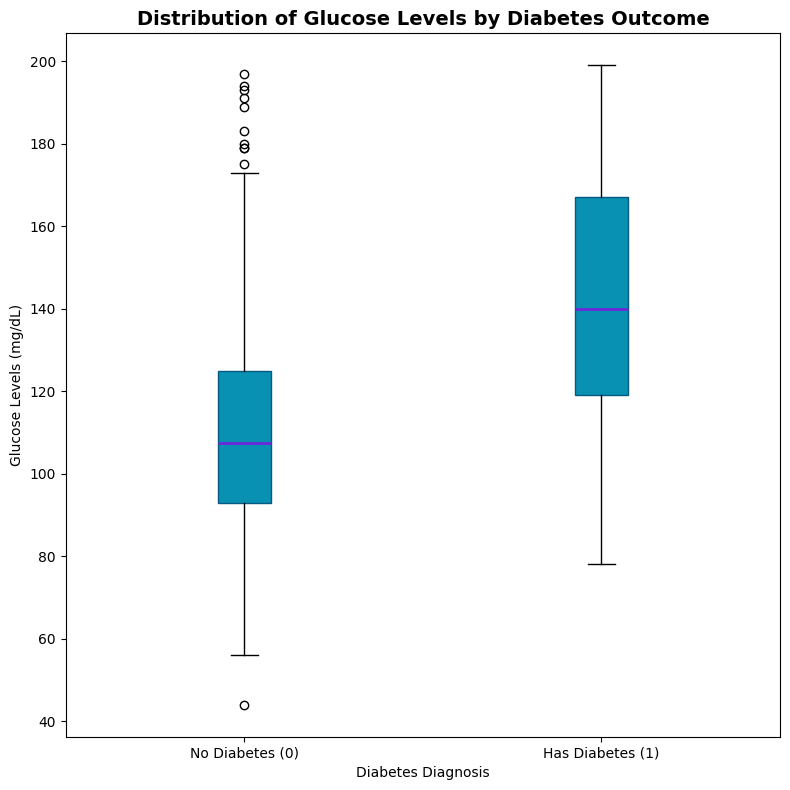

In [ ]:
# Importing dependencies
import matplotlib.pyplot as plt

# Grouping glucose data by the target outcome for boxplotting
glucose_no_diabetes = data[data["outcome(target)"] == 0]["Glucose"]
glucose_has_diabetes = data[data["outcome(target)"] == 1]["Glucose"]

plt.figure(figsize=(8, 8))
plt.boxplot([glucose_no_diabetes, glucose_has_diabetes],
            labels=["No Diabetes (0)", "Has Diabetes (1)"],
            patch_artist=True,
            boxprops=dict(facecolor="#0891B2", color="#065A82"),
            medianprops=dict(color="#6D28D9", linewidth=2))

plt.title("Distribution of Glucose Levels by Diabetes Outcome",
          fontsize=14, fontweight="bold")

plt.xlabel("Diabetes Diagnosis")

plt.ylabel("Glucose Levels (mg/dL)")

plt.tight_layout()

plt.show()

#### **Fig 3**

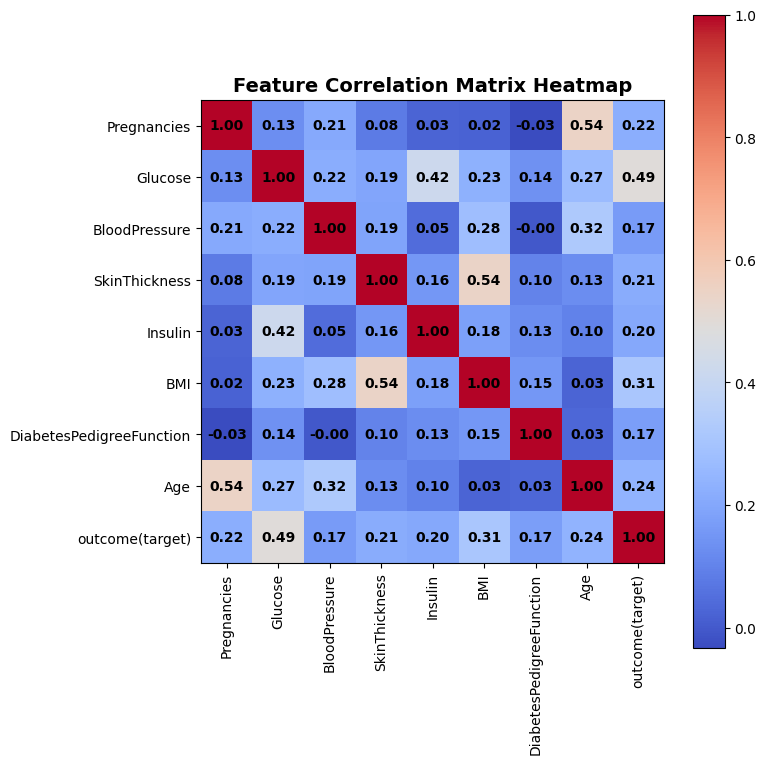

In [ ]:
# Importing dependencies
import matplotlib.pyplot as plt

# Computing the correlation matrix dataframe
correlation_matrix = data.corr()

plt.figure(figsize=(8, 8))
plt.imshow(correlation_matrix, cmap="coolwarm", interpolation="none")
plt.colorbar()

# Setting the axis tick marks and labels
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)

# Adding the exact correlation numbers on the grid
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(j, i, f"{correlation_matrix.iloc[i, j]:.2f}",
                 ha="center", va="center", color="black", fontweight="bold")

plt.title("Feature Correlation Matrix Heatmap",
          fontsize=14, fontweight="bold")

plt.tight_layout()

plt.show()

###**Machine Learning Model development**

In [ ]:
#importing dependency
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.model_selection import train_test_split

In [ ]:
# Split features (X) and label (y)
X = data.drop(columns=['outcome(target)'])
y = data['outcome(target)']

In [ ]:
# Train/Test split: 80% to train the model, 20% to test it
# 'stratify=y' ensures the 34.9% diabetes ratio stays identical in both set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Train the Logistic Regression Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# Generate Predictions on the unseen Test data
y_pred = model.predict(X_test)

In [ ]:
# PRINT OUT EVALUATION NUMBERS
print("==================================================================")
print("🎯 FINAL CAPSTONE MODEL PERFORMANCE METRICS")
print("==================================================================")
print(f"Accuracy Score:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision Score: {precision_score(y_test, y_pred):.4f}")
print(f"Recall Score:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:        {f1_score(y_test, y_pred):.4f}")

🎯 FINAL CAPSTONE MODEL PERFORMANCE METRICS
Accuracy Score:  0.7013
Precision Score: 0.5870
Recall Score:    0.5000
F1 Score:        0.5400


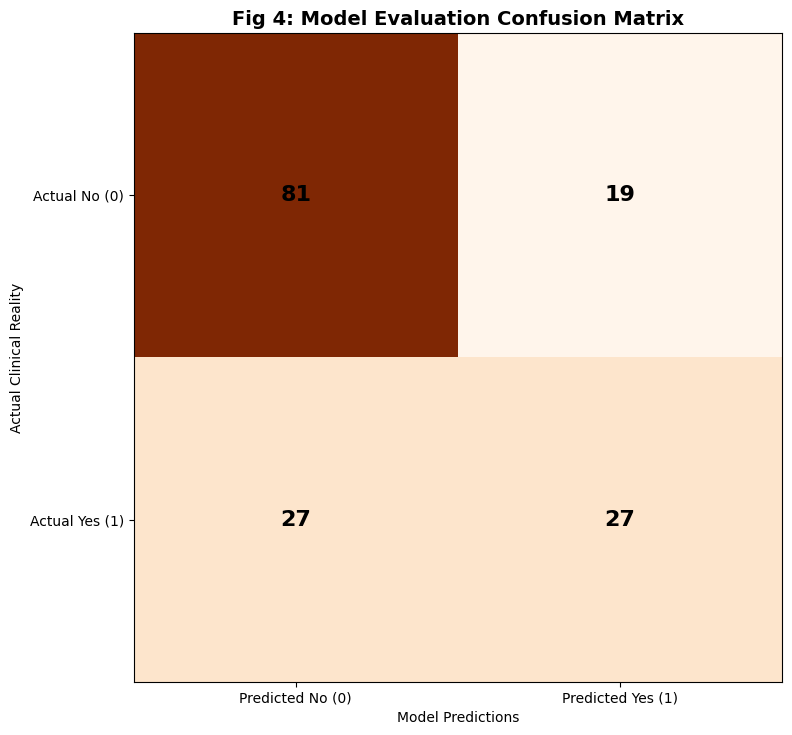

In [ ]:
# VISUALIZE CONFUSION MATRIX (USING MATPLOTLIB FORMAT)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 8))
plt.imshow(cm, cmap="Oranges", interpolation="none")

# Setting labels matching your clean styling format
plt.xticks([0, 1], ["Predicted No (0)", "Predicted Yes (1)"])
plt.yticks([0, 1], ["Actual No (0)", "Actual Yes (1)"])

# Write numbers directly inside the matrix grid squares
for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{cm[i, j]}",
                 ha="center", va="center", color="black", fontsize=16, fontweight="bold")

plt.title("Fig 4: Model Evaluation Confusion Matrix", fontsize=14, fontweight="bold")
plt.xlabel("Model Predictions")
plt.ylabel("Actual Clinical Reality")
plt.tight_layout()
plt.show()